<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/Kuantum_Churn_Algoritmalari_Telco_Qiskit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kuantum Churn Algoritmaları – Telco Sektörü (Qiskit)

**Karşılaştırma Tablosundaki Algoritmalar:**
- **VQC / QNN** – Variational Quantum Classifier / Quantum Neural Network  
- **QSVM** – Quantum Support Vector Machine (Quantum Kernel)  
- **Kuantum Topluluk** – Hybrid Quantum Ensemble (Bagging)  
- **QPCA** – Quantum Kernel Principal Component Analysis  
- **QBM** – Quantum Boltzmann Machine (kavramsal + basitleştirilmiş demo)

Bu notebook, **NISQ** dönemi için tasarlanmıştır. Gerçek telco churn verisi yerine, aynı özellik dağılımlarını taklit eden **sentetik bir veri seti** kullanılır. Qubit sayısı düşük tutulur (4–6) ki Colab simülatöründe ve gelecekte gerçek donanımda çalıştırılabilsin.

> **Not:** Qiskit Machine Learning sürümleri hızla değişiyor. Aşağıdaki kurulum hücreleri güncel paketleri çeker. Hata alırsanız `qiskit-machine-learning` sürümünü kontrol edin.

## 0. Kurulum (Google Colab)

In [ ]:
# Colab için gerekli paketler
!pip install -q --upgrade pip
!pip install -q qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms
!pip install -q scikit-learn pandas numpy matplotlib seaborn pylatexenc

print("Kurulum tamamlandı.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.1 MB/s eta 0:00:00
Kurulum tamamlandı.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

# Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, EfficientSU2, PauliFeatureMap
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA, SPSA, ADAM
from qiskit_machine_learning.algorithms import VQC, QSVC
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 42
np.random.seed(42)

print("Kütüphaneler yüklendi.")
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Kütüphaneler yüklendi.
Qiskit version: 2.5.1


## 1. Sentetik Telco Churn Veri Seti

Gerçek telco churn veri setlerindeki tipik özellikler:
- `tenure` (ay cinsinden abonelik süresi)
- `MonthlyCharges`, `TotalCharges`
- `Contract` (aylık / 1 yıllık / 2 yıllık)
- `InternetService`, `OnlineSecurity`, `TechSupport`
- `PaymentMethod`, demografik bilgiler

NISQ için **4 özellik** seçiyoruz (4 qubit). Gerçek projede PCA veya feature selection ile 4–8 feature’a indirilir.

In [ ]:
def generate_telco_churn(n_samples=400, random_state=42):
    """Sentetik telco churn verisi üretir."""
    rng = np.random.RandomState(random_state)

    # Özellikler
    tenure = rng.randint(1, 73, size=n_samples)                     # 1-72 ay
    monthly_charges = rng.uniform(20, 120, size=n_samples)          # $20-120
    contract_type = rng.choice([0, 1, 2], size=n_samples, p=[0.55, 0.25, 0.20])  # 0=aylık, 1=1y, 2=2y
    support_tickets = rng.poisson(1.5, size=n_samples)              # destek talebi sayısı
    # Ek özellikler (ileride kullanılabilir)
    data_usage_gb = rng.exponential(15, size=n_samples)
    age = rng.randint(18, 75, size=n_samples)

    # Churn olasılığı (gerçekçi kurallar)
    # Düşük tenure + yüksek ücret + aylık sözleşme + çok ticket → churn riski yüksek
    logit = (
        -0.06 * tenure
        + 0.025 * monthly_charges
        - 0.9 * contract_type
        + 0.35 * support_tickets
        - 1.8
    )
    prob = 1 / (1 + np.exp(-logit))
    churn = (rng.rand(n_samples) < prob).astype(int)

    df = pd.DataFrame({
        "tenure": tenure,
        "MonthlyCharges": monthly_charges,
        "Contract": contract_type,
        "SupportTickets": support_tickets,
        "DataUsageGB": data_usage_gb,
        "Age": age,
        "Churn": churn
    })
    return df

df = generate_telco_churn(n_samples=400)
print("Veri seti şekli:", df.shape)
print("\nChurn dağılımı:")
print(df["Churn"].value_counts(normalize=True).round(3))
df.head()

Veri seti şekli: (400, 7)

Churn dağılımı:
Churn
0    0.835
1    0.165
Name: proportion, dtype: float64


,tenure,MonthlyCharges,Contract,SupportTickets,DataUsageGB,Age,Churn
0,52,114.023024,2,1,17.391073,72,0
1,15,77.547418,1,1,1.082774,44,0
2,72,58.816993,0,2,2.883423,71,0
3,61,84.328822,0,3,29.041786,46,0
4,21,65.825289,0,1,3.865628,56,0


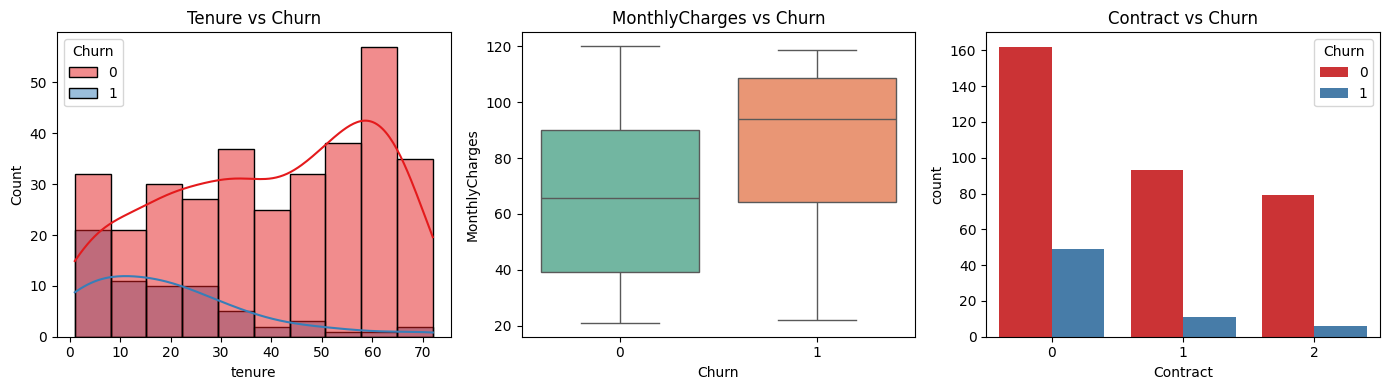

In [ ]:
# Görselleştirme
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, ax=axes[0], palette="Set1")
axes[0].set_title("Tenure vs Churn")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette="Set2")
axes[1].set_title("MonthlyCharges vs Churn")
sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[2], palette="Set1")
axes[2].set_title("Contract vs Churn")
plt.tight_layout()
plt.show()

### Özellik seçimi ve ölçekleme (NISQ için 4 özellik)

In [ ]:
FEATURE_COLS = ["tenure", "MonthlyCharges", "Contract", "SupportTickets"]
X = df[FEATURE_COLS].values.astype(float)
y = df["Churn"].values

# MinMax → [0, π] aralığı (açı kodlama için uygun)
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn oranı: {y_train.mean():.3f}")
print(f"Test  churn oranı: {y_test.mean():.3f}")

Train: (300, 4), Test: (100, 4)
Train churn oranı: 0.167
Test  churn oranı: 0.160


## 2. Klasik Baseline (karşılaştırma için)

In [ ]:
def evaluate(y_true, y_pred, name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results = []

# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append(evaluate(y_test, y_pred_lr, "Classical Logistic Regression"))

# Classical SVM (RBF)
svc = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
results.append(evaluate(y_test, y_pred_svc, "Classical SVM (RBF)"))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate(y_test, y_pred_rf, "Classical Random Forest"))


=== Classical Logistic Regression ===
Accuracy : 0.8100
Precision: 0.2857
Recall   : 0.1250
F1-Score : 0.1739

=== Classical SVM (RBF) ===
Accuracy : 0.8500
Precision: 0.5714
Recall   : 0.2500
F1-Score : 0.3478

=== Classical Random Forest ===
Accuracy : 0.8200
Precision: 0.4000
Recall   : 0.2500
F1-Score : 0.3077


## 3. VQC / QNN – Variational Quantum Classifier

**Tabloya göre:**
- İşlem karmaşıklığı: Düşük – Orta  
- Kübit gereksinimi: Az (10–50, burada 4)  
- NISQ uygunluğu: **Yüksek (günümüz için en ideali)**  
- En iyi kullanım: Davranışsal korelasyonlar ve anlık churn tespiti

VQC, bir **feature map** + **parametreli ansatz** kullanır. Eğitim klasik optimizer (COBYLA) ile yapılır.

Feature Map derinlik: 1
Ansatz parametre sayısı: 12


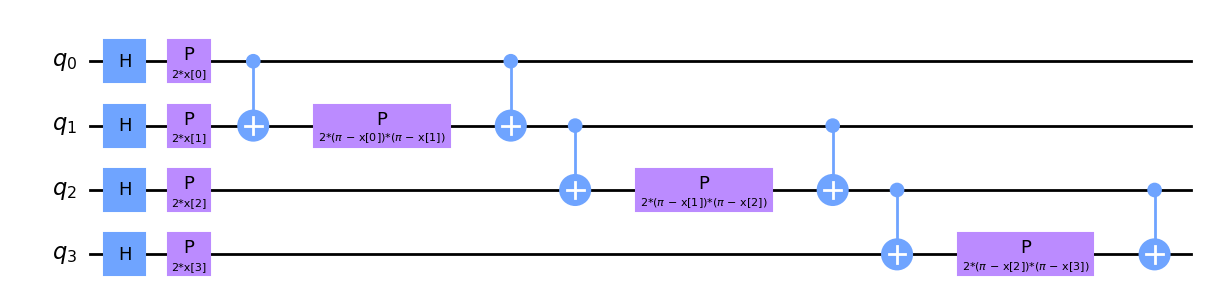

In [ ]:
num_qubits = X_train.shape[1]  # 4

# Feature Map: ZZFeatureMap – entangle ederek non-lineer özellikler üretir
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1, entanglement="linear")

# Ansatz: RealAmplitudes – NISQ-dostu, sığ devre
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2, entanglement="linear")

print("Feature Map derinlik:", feature_map.depth())
print("Ansatz parametre sayısı:", ansatz.num_parameters)
feature_map.decompose().draw("mpl", style="clifford")

In [ ]:
# Sampler (statevector – gürültüsüz simülasyon)
sampler = StatevectorSampler()

# VQC oluştur
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=60),
    sampler=sampler,
)

print("VQC eğitimi başlıyor (birkaç dakika sürebilir)...")
vqc.fit(X_train, y_train)

y_pred_vqc = vqc.predict(X_test)
results.append(evaluate(y_test, y_pred_vqc, "VQC / QNN"))

print("\nTrain skoru:", round(vqc.score(X_train, y_train), 4))
print("Test  skoru:", round(vqc.score(X_test, y_test), 4))

VQC eğitimi başlıyor (birkaç dakika sürebilir)...

=== VQC / QNN ===
Accuracy : 0.5600
Precision: 0.1818
Recall   : 0.5000
F1-Score : 0.2667

Train skoru: 0.5933
Test  skoru: 0.55


## 4. QSVM – Quantum Support Vector Machine

**Tabloya göre:**
- İşlem karmaşıklığı: Orta  
- Kübit: Orta (50–100 ideal, burada 4)  
- NISQ: Orta – Yüksek (gürültüye hassas)  
- En iyi kullanım: Paket türü, fatura ve demografik segmentasyon

Quantum Kernel, veriyi Hilbert uzayına gömer; klasik SVM bu kernel ile eğitilir.

In [ ]:
# Quantum Kernel
fm_qsvm = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement="linear")
sampler_kernel = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler_kernel)
quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=fm_qsvm)

# QSVC (Qiskit Machine Learning)
qsvc = QSVC(quantum_kernel=quantum_kernel)
print("QSVM eğitimi başlıyor...")
qsvc.fit(X_train, y_train)

y_pred_qsvc = qsvc.predict(X_test)
results.append(evaluate(y_test, y_pred_qsvc, "QSVM (Quantum Kernel)"))

print("\nTrain skoru:", round(qsvc.score(X_train, y_train), 4))
print("Test  skoru:", round(qsvc.score(X_test, y_test), 4))

QSVM eğitimi başlıyor...

=== QSVM (Quantum Kernel) ===
Accuracy : 0.8400
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000

Train skoru: 0.84
Test  skoru: 0.84


### Alternatif: Klasik SVM + Quantum Kernel (manuel)

In [ ]:
# Kernel matrislerini önceden hesapla (daha şeffaf)
print("Kernel matrisi hesaplanıyor...")
K_train = quantum_kernel.evaluate(x_vec=X_train)
K_test = quantum_kernel.evaluate(x_vec=X_test, y_vec=X_train)

svc_qk = SVC(kernel="precomputed")
svc_qk.fit(K_train, y_train)
y_pred_qk = svc_qk.predict(K_test)
results.append(evaluate(y_test, y_pred_qk, "SVM + Precomputed Quantum Kernel"))

Kernel matrisi hesaplanıyor...

=== SVM + Precomputed Quantum Kernel ===
Accuracy : 0.8400
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000


## 5. Kuantum Topluluk (Quantum Ensemble – Hybrid Bagging)

**Tabloya göre:**
- Karmaşıklık: Yüksek  
- Kübit: Hibrit (değişken)  
- NISQ: Orta (Klasik-Kuantum hibrit)  
- En iyi kullanım: Maksimum tahmin doğruluğu hedeflenen projeler

Saf kuantum bagging (süperpozisyonla B model) henüz pratik değil.  
Burada **hibrit yaklaşım** kullanıyoruz: birden fazla farklı feature map / ansatz ile VQC veya quantum kernel eğitip oylama (voting) yapıyoruz.

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class SimpleQuantumVoter(BaseEstimator, ClassifierMixin):
    """Birden fazla VQC'yi bagging tarzı birleştirir."""
    def __init__(self, n_estimators=3, maxiter=40):
        self.n_estimators = n_estimators
        self.maxiter = maxiter
        self.models_ = []

    def fit(self, X, y):
        self.models_ = []
        n = X.shape[1]
        sampler = StatevectorSampler()
        for i in range(self.n_estimators):
            # Farklı reps / entanglement ile çeşitlilik
            fm = ZZFeatureMap(feature_dimension=n, reps=1 + (i % 2), entanglement="linear")
            ans = RealAmplitudes(num_qubits=n, reps=1 + (i % 2), entanglement="circular" if i % 2 else "linear")
            model = VQC(
                feature_map=fm,
                ansatz=ans,
                optimizer=COBYLA(maxiter=self.maxiter),
                sampler=sampler,
            )
            # Bootstrap örnekleme
            idx = np.random.choice(len(X), size=len(X), replace=True)
            model.fit(X[idx], y[idx])
            self.models_.append(model)
            print(f"  Ensemble üye {i+1}/{self.n_estimators} eğitildi.")
        return self

    def predict(self, X):
        preds = np.array([m.predict(X) for m in self.models_])
        # Çoğunluk oylaması
        return np.round(preds.mean(axis=0)).astype(int)

print("Kuantum Ensemble (3 VQC) eğitimi başlıyor...")
q_ensemble = SimpleQuantumVoter(n_estimators=3, maxiter=35)
q_ensemble.fit(X_train, y_train)
y_pred_ens = q_ensemble.predict(X_test)
results.append(evaluate(y_test, y_pred_ens, "Kuantum Topluluk (Hybrid Bagging)"))

Kuantum Ensemble (3 VQC) eğitimi başlıyor...


  Ensemble üye 1/3 eğitildi.


  Ensemble üye 2/3 eğitildi.
  Ensemble üye 3/3 eğitildi.

=== Kuantum Topluluk (Hybrid Bagging) ===
Accuracy : 0.5000
Precision: 0.1600
Recall   : 0.5000
F1-Score : 0.2424


## 6. QPCA – Quantum Kernel Principal Component Analysis

**Tabloya göre:**
- Karmaşıklık: Çok Yüksek  
- Kübit: Yüksek + derin devreler  
- NISQ: Düşük (geleceğin teknolojisi)  
- En iyi kullanım: Milyonlarca satırlık çağrı/veri trafiği sadeleştirme

Burada **Quantum Kernel PCA** kullanıyoruz (FidelityQuantumKernel + scikit-learn KernelPCA).  
Tam QPE tabanlı qPCA şu an NISQ için pratik değildir.

Quantum kernel matrisi (train) hesaplanıyor...
QPCA sonrası şekil: (300, 2)


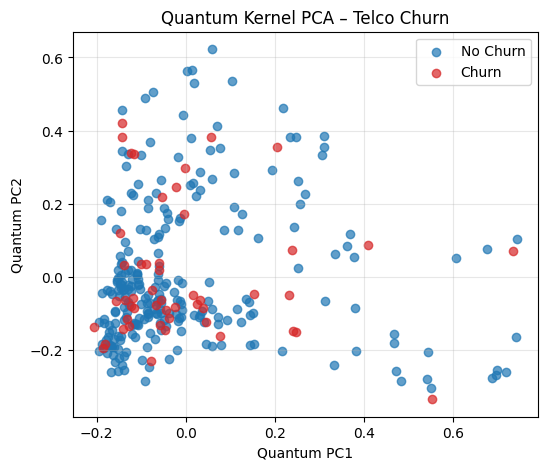


=== QPCA (Quantum Kernel PCA + LR) ===
Accuracy : 0.8400
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000


In [ ]:
from sklearn.decomposition import KernelPCA

# Quantum kernel ile 2 bileşene indir
fm_pca = ZZFeatureMap(feature_dimension=num_qubits, reps=1, entanglement="linear")
fidelity_pca = ComputeUncompute(sampler=StatevectorSampler())
qpca_kernel = FidelityQuantumKernel(fidelity=fidelity_pca, feature_map=fm_pca)

print("Quantum kernel matrisi (train) hesaplanıyor...")
K_train_pca = qpca_kernel.evaluate(x_vec=X_train)
K_test_pca = qpca_kernel.evaluate(x_vec=X_test, y_vec=X_train)

kpca = KernelPCA(n_components=2, kernel="precomputed")
X_train_q = kpca.fit_transform(K_train_pca)
X_test_q = kpca.transform(K_test_pca)

print("QPCA sonrası şekil:", X_train_q.shape)

# Görselleştir
plt.figure(figsize=(6, 5))
plt.scatter(X_train_q[y_train==0, 0], X_train_q[y_train==0, 1], c="tab:blue", label="No Churn", alpha=0.7)
plt.scatter(X_train_q[y_train==1, 0], X_train_q[y_train==1, 1], c="tab:red", label="Churn", alpha=0.7)
plt.xlabel("Quantum PC1")
plt.ylabel("Quantum PC2")
plt.title("Quantum Kernel PCA – Telco Churn")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# İndirgenmiş uzayda klasik sınıflandırıcı
lr_qpca = LogisticRegression(max_iter=300)
lr_qpca.fit(X_train_q, y_train)
y_pred_qpca = lr_qpca.predict(X_test_q)
results.append(evaluate(y_test, y_pred_qpca, "QPCA (Quantum Kernel PCA + LR)"))

## 7. QBM – Quantum Boltzmann Machine (Kavramsal + Basitleştirilmiş Demo)

**Tabloya göre:**
- Karmaşıklık: Çok Yüksek  
- Kübit: Çok yüksek (hata toleranslı)  
- NISQ: Düşük (geleceğin teknolojisi)  
- En iyi kullanım: Uzun vadeli müşteri eğilimleri ve simülasyonlar

QBM, kuantum Hamiltonyen üzerinden Boltzmann dağılımı öğrenir.  
Tam eğitim (VarQITE / Gibbs state hazırlama) şu an simülatörde bile pahalıdır.  
Aşağıda **enerji tabanlı basitleştirilmiş bir yaklaşım** ve teorik çerçeve sunuluyor.

In [ ]:
# --- Basitleştirilmiş Enerji Tabanlı Model (Klasik BM benzeri, kuantum ilhamlı) ---
# Gerçek QBM için: transverse-field Ising Hamiltonian + Gibbs state sampling gerekir.

from scipy.optimize import minimize

def classical_boltzmann_like(X, y, n_hidden=4, maxiter=80):
    """
    Basit restricted Boltzmann machine benzeri enerji modeli.
    QBM'nin klasik limitini gösterir; gerçek QBM için quantum imaginary time evolution gerekir.
    """
    n_vis = X.shape[1]
    # Parametreler: W (visible-hidden), b (visible bias), c (hidden bias)
    n_params = n_vis * n_hidden + n_vis + n_hidden
    theta0 = np.random.randn(n_params) * 0.1

    def unpack(theta):
        W = theta[:n_vis*n_hidden].reshape(n_vis, n_hidden)
        b = theta[n_vis*n_hidden:n_vis*n_hidden+n_vis]
        c = theta[-n_hidden:]
        return W, b, c

    def free_energy(x, W, b, c):
        # F(v) = -b·v - Σ log(1 + exp(c + Wᵀv))
        visible_term = -np.dot(x, b)
        hidden_term = -np.sum(np.logaddexp(0, c + x @ W), axis=-1)
        return visible_term + hidden_term

    def loss(theta):
        W, b, c = unpack(theta)
        # İki sınıf için ayrı enerji; softmax benzeri
        fe0 = free_energy(X[y==0], W, b, c).mean() if np.any(y==0) else 0
        fe1 = free_energy(X[y==1], W, b, c).mean() if np.any(y==1) else 0
        # Basit margin: churn sınıfının enerjisi düşük olsun
        return fe1 - fe0 + 0.01 * np.sum(theta**2)

    res = minimize(loss, theta0, method="L-BFGS-B", options={"maxiter": maxiter})
    W, b, c = unpack(res.x)

    # Tahmin: enerji farkına göre
    def predict(Xnew):
        fe = free_energy(Xnew, W, b, c)
        # Düşük enerji → churn (sınıf 1) varsayımı (eğitimde böyle yönlendirdik)
        threshold = np.median(free_energy(X, W, b, c))
        return (fe < threshold).astype(int)

    return predict

print("Basitleştirilmiş enerji modeli eğitiliyor (QBM ilhamlı)...")
qbm_predict = classical_boltzmann_like(X_train, y_train, n_hidden=4, maxiter=60)
y_pred_qbm = qbm_predict(X_test)
results.append(evaluate(y_test, y_pred_qbm, "QBM-inspired (Classical Energy Model)"))

print("""
Not: Gerçek Quantum Boltzmann Machine için:
  - Transverse-field Ising Hamiltonian tanımlanır
  - Gibbs durumu (e^{-βH}/Z) variational imaginary time evolution (VarQITE) ile hazırlanır
  - Gradientler quantum expectation değerlerinden alınır
  - Bu, hata toleranslı kuantum bilgisayarlar gerektirir.
""")

Basitleştirilmiş enerji modeli eğitiliyor (QBM ilhamlı)...

=== QBM-inspired (Classical Energy Model) ===
Accuracy : 0.6000
Precision: 0.2600
Recall   : 0.8125
F1-Score : 0.3939

Not: Gerçek Quantum Boltzmann Machine için:
  - Transverse-field Ising Hamiltonian tanımlanır
  - Gibbs durumu (e^{-βH}/Z) variational imaginary time evolution (VarQITE) ile hazırlanır
  - Gradientler quantum expectation değerlerinden alınır
  - Bu, hata toleranslı kuantum bilgisayarlar gerektirir.



## 8. Sonuçların Karşılaştırılması


MODEL KARŞILAŞTIRMA TABLOSU (Test Seti)


,model,accuracy,precision,recall,f1
0,QBM-inspired (Classical Energy Model),0.60,0.2600,0.8125,0.3939
1,Classical SVM (RBF),0.85,0.5714,0.2500,0.3478
2,Classical Random Forest,0.82,0.4000,0.2500,0.3077
3,VQC / QNN,0.56,0.1818,0.5000,0.2667
4,Kuantum Topluluk (Hybrid Bagging),0.50,0.1600,0.5000,0.2424
5,Classical Logistic Regression,0.81,0.2857,0.1250,0.1739
6,QSVM (Quantum Kernel),0.84,0.0000,0.0000,0.0000
7,SVM + Precomputed Quantum Kernel,0.84,0.0000,0.0000,0.0000
8,QPCA (Quantum Kernel PCA + LR),0.84,0.0000,0.0000,0.0000


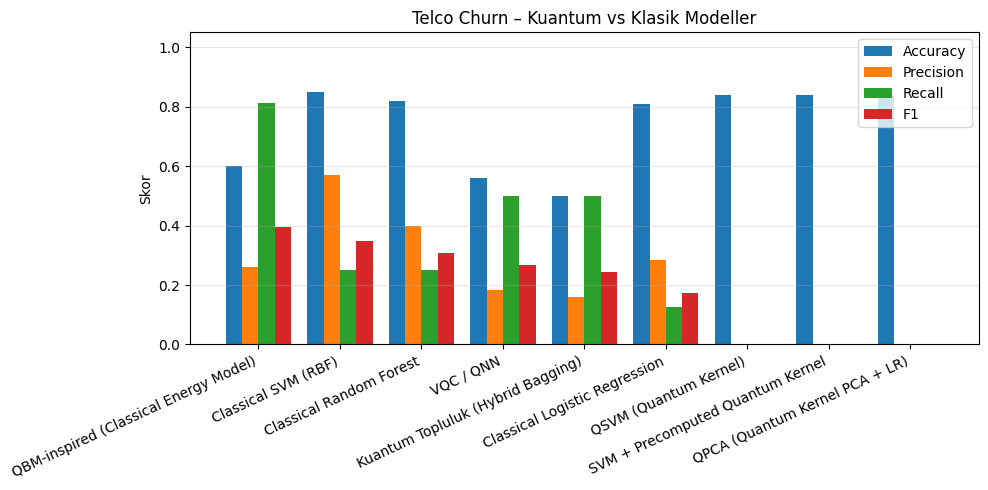

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
print("\n" + "="*60)
print("MODEL KARŞILAŞTIRMA TABLOSU (Test Seti)")
print("="*60)
display(results_df.round(4))

# Bar plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2
ax.bar(x - 1.5*width, results_df["accuracy"], width, label="Accuracy")
ax.bar(x - 0.5*width, results_df["precision"], width, label="Precision")
ax.bar(x + 0.5*width, results_df["recall"], width, label="Recall")
ax.bar(x + 1.5*width, results_df["f1"], width, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(results_df["model"], rotation=25, ha="right")
ax.set_ylabel("Skor")
ax.set_title("Telco Churn – Kuantum vs Klasik Modeller")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Orijinal Karşılaştırma Tablosu ile Özet

| Algoritma Türü | İşlem Karmaşıklığı | Kübit Devre Gereksinimi | Donanım Uygunluğu (NISQ)* | Telco Verisindeki En İyi Kullanım Alanı |
|----------------|--------------------|--------------------------|---------------------------|------------------------------------------|
| **VQC / QNN** | Düşük – Orta | Az sayıda kübit (10–50) | **Yüksek (Günümüz için en ideali)** | Davranışsal korelasyonlar ve anlık churn tespiti |
| **QSVM** | Orta | Orta düzey kübit (50–100) | Orta – Yüksek (Gürültüye hassas) | Paket türü, fatura ve demografik segmentasyon |
| **Kuantum Topluluk** | Yüksek | Hibrit (Değişken) | Orta (Klasik-Kuantum hibrit) | Maksimum tahmin doğruluğu hedeflenen projeler |
| **QPCA** | Çok Yüksek | Yüksek kübit ve derin devreler | Düşük (Geleceğin teknolojisi) | Milyonlarca satırlık çağrı/veri trafiği sadeleştirme |
| **QBM** | Çok Yüksek | Çok yüksek kübit (Hata toleranslı) | Düşük (Geleceğin teknolojisi) | Uzun vadeli müşteri eğilimleri ve simülasyonlar |

### Pratik Öneriler (Telco)
1. **Hemen başlamak için** → **VQC / QNN** (4–8 feature + PCA). Colab’da simüle edilebilir, IBM Quantum’a da gönderilebilir.
2. **Segmentasyon & kernel yöntemleri** → **QSVM**. Özellik sayısı arttıkça kernel hesaplama maliyeti artar; batch’leyin.
3. **Yüksek doğruluk hedefi** → Hibrit ensemble (birkaç VQC + klasik modeller voting).
4. **Büyük ölçekli özellik indirgeme** → Quantum Kernel PCA (şimdilik), ileride tam qPCA.
5. **Generative / uzun vadeli simülasyon** → QBM (hata toleranslı donanım gelince).

## 10. Gerçek Donanıma Gönderme (Opsiyonel)

IBM Quantum Runtime kullanmak için:
```python
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

service = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_TOKEN")
backend = service.least_busy(operational=True, simulator=False)
sampler = SamplerV2(mode=backend)
# VQC veya kernel oluştururken sampler=sampler verin
```

Gürültü mitigation (TREX, ZNE, PEC) eklemeyi unutmayın.

## 11. Sonraki Adımlar

- Gerçek Telco Customer Churn (Kaggle) veri setini yükleyip aynı pipeline’ı çalıştırın.
- Feature sayısını 6–8’e çıkarıp `EfficientSU2` ansatz deneyin.
- `qiskit-machine-learning` içindeki `NeuralNetworkClassifier` + `TorchConnector` ile hibrit klasik-kuantum ağlar kurun.
- QBM için `qiskit-algorithms` VarQITE örneklerini inceleyin.
- Production’da: feature store + model registry + A/B test (kuantum skor vs klasik skor).

**Kaynaklar**
- [Qiskit Machine Learning Tutorials](https://qiskit-community.github.io/qiskit-machine-learning/)
- [Quantum Kernel Tutorial](https://qiskit-community.github.io/qiskit-machine-learning/tutorials/03_quantum_kernel.html)
- [VQC Tutorial](https://qiskit-community.github.io/qiskit-machine-learning/tutorials/02_neural_network_classifier_and_regressor.html)

---
*Notebook, tablodaki beş algoritmayı NISQ-uyumlu ve eğitim amaçlı şekilde kapsar. Başarılar!*